# CIC preliminary analysis

In [1]:
# Load dependencies and make src/ importable from the notebook.
from pathlib import Path
import sys
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt

root = Path.cwd()
sys.path.insert(0, str(root.parent / "src"))
    
from utils_dfs_load import *


## Load and check null

In [2]:
# Merge CIC data with commune/arrondissement geometries.
gdf = merge_cic_communes_then_arrondissements(verbose=True)

Dropping the following communes/arrondissements with missing geometry:
<StringArray>
['SANNERVILLE', 'BERNIERES-SUR-SEINE']
Length: 2, dtype: string


In [3]:
# Check missing values per column.
gdf.isna().sum().sort_values(ascending=False)

code_insee     2109764
code              2290
dep                  0
nomdep               0
codecommune          0
nomcommune           0
plm                  0
paris                0
value                0
metric               0
year                 0
geometry             0
dtype: int64

## Check overlappings between polygons are irrelevant.

In [4]:
# Compute total pairwise overlap area between unique commune geometries.
gdf_unique = gdf.groupby("codecommune").first().reset_index(drop=True)
g = gdf_unique.reset_index(drop=True)[["geometry"]].copy()

pairs = gpd.sjoin(g, g, predicate="intersects", how="inner")
pairs = pairs[pairs.index < pairs.index_right]

geom_left = g.loc[pairs.index, "geometry"].to_numpy()
geom_right = g.loc[pairs.index_right, "geometry"].to_numpy()

intersect_area = gpd.GeoSeries(geom_left).intersection(gpd.GeoSeries(geom_right)).area.sum()


In [5]:
# Compare overlap area to the total covered area.
tot_area = gdf_unique.geometry.union_all().area

print(np.round(intersect_area/tot_area,4))

0.0007


## Preliminary analysis (prixbien)

In [6]:
mask = gdf["metric"]=="prixbien"
gdf_prixbien = gdf[mask]

count    1.817718e+06
mean     7.610797e+04
std      6.622615e+04
min      3.083687e+02
25%      2.822923e+04
50%      5.638621e+04
75%      1.080572e+05
max      1.878612e+06
Name: value, dtype: float64


<Axes: ylabel='Frequency'>

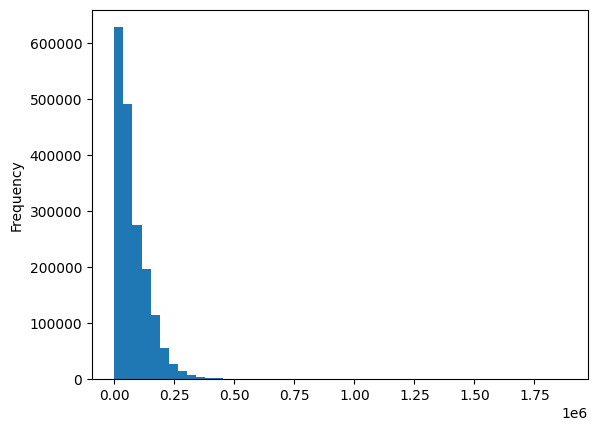

In [8]:
# Distribution of value.
print(gdf_prixbien["value"].describe())
gdf_prixbien["value"].plot.hist(bins=50)


<Axes: xlabel='year'>

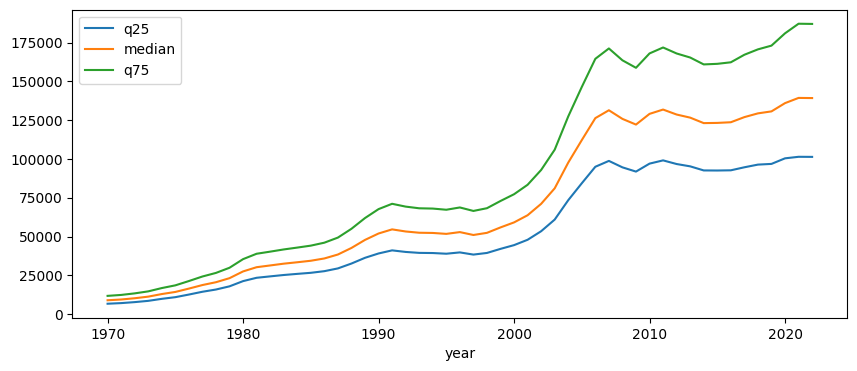

In [9]:
# Distribution of value by year (quartiles).
year_q = (
    gdf_prixbien.groupby("year")["value"]
    .quantile([0.25, 0.5, 0.75])
    .unstack()
)
year_q.columns = ["q25", "median", "q75"]
year_q.plot(figsize=(10, 4))


<Axes: xlabel='dep'>

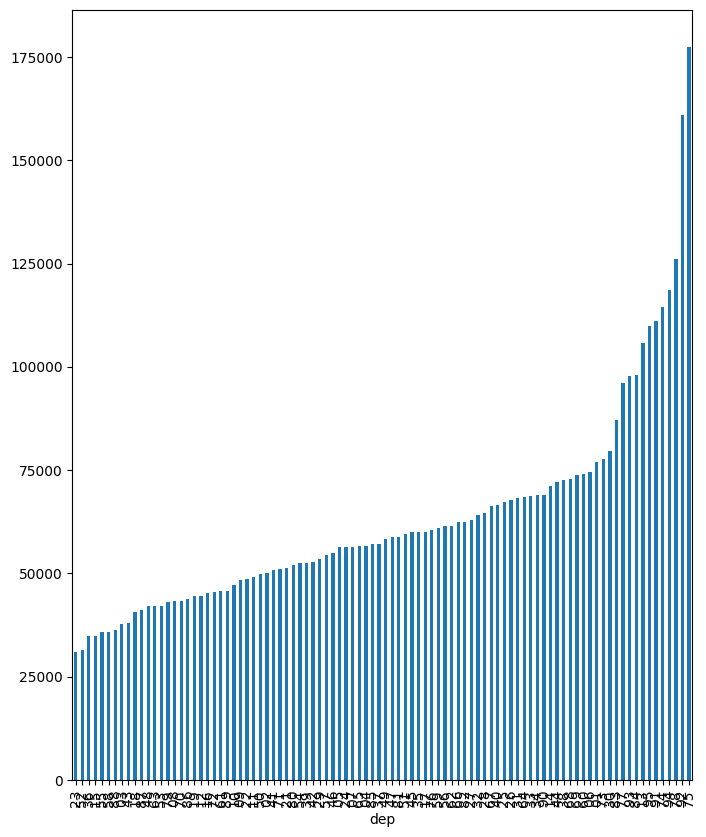

In [10]:
# Distribution of value by dep (median).
dep_median = gdf_prixbien.groupby("dep")["value"].median().sort_values()
dep_median.plot(kind="bar", figsize=(8, 10))


Text(0.5, 1.0, 'Median prixbien by dep and year (top 20 deps)')

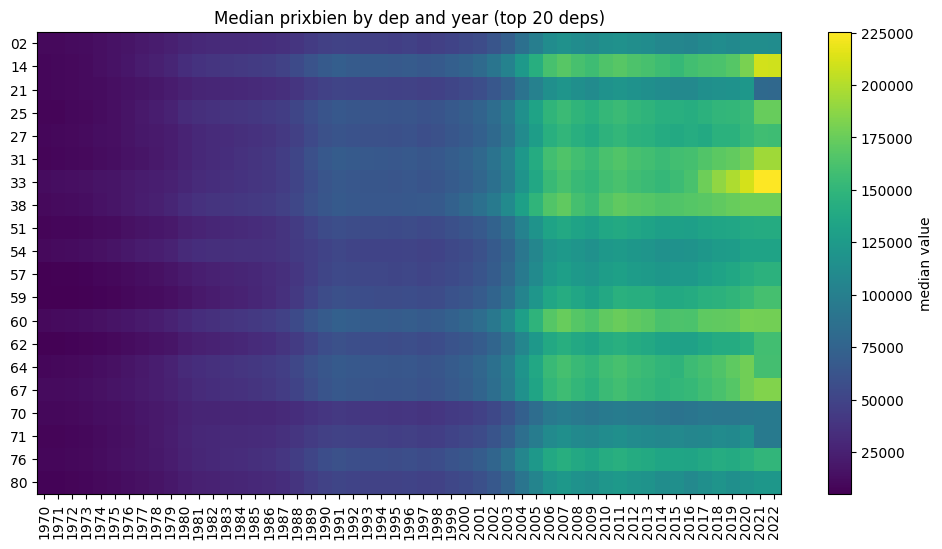

In [11]:
# Distribution of value by dep and year (median heatmap for top deps).
top_deps = (
    gdf_prixbien.groupby("dep")["value"].count().sort_values(ascending=False).head(20).index
)
dep_year = (
    gdf_prixbien[gdf_prixbien["dep"].isin(top_deps)]
    .pivot_table(index="dep", columns="year", values="value", aggfunc="median")
)
plt.figure(figsize=(12, 6))
plt.imshow(dep_year, aspect="auto")
plt.yticks(range(len(dep_year.index)), dep_year.index)
plt.xticks(range(len(dep_year.columns)), dep_year.columns, rotation=90)
plt.colorbar(label="median value")
plt.title("Median prixbien by dep and year (top 20 deps)")


In [12]:
# Basic outlier cleanup using IQR. coefficient of 2.5 to leave fat tails.
q1 = gdf_prixbien["value"].quantile(0.25)
q3 = gdf_prixbien["value"].quantile(0.75)
iqr = q3 - q1
lower = q1 - 2.5 * iqr
upper = q3 + 2.5 * iqr
gdf_prixbien_clean = gdf_prixbien[gdf_prixbien["value"].between(lower, upper)]
print(
    f"Dropped {len(gdf_prixbien) - len(gdf_prixbien_clean)} rows as outliers,"
    f"{len(gdf_prixbien_clean) / len(gdf_prixbien) - 1}, of the total"
)


Dropped 14656 rows as outliers,-0.008062856834778587, of the total


count    1.803062e+06
mean     7.349602e+04
std      5.873525e+04
min      3.083687e+02
25%      2.803515e+04
50%      5.582491e+04
75%      1.063619e+05
max      3.076232e+05
Name: value, dtype: float64


<Axes: ylabel='Frequency'>

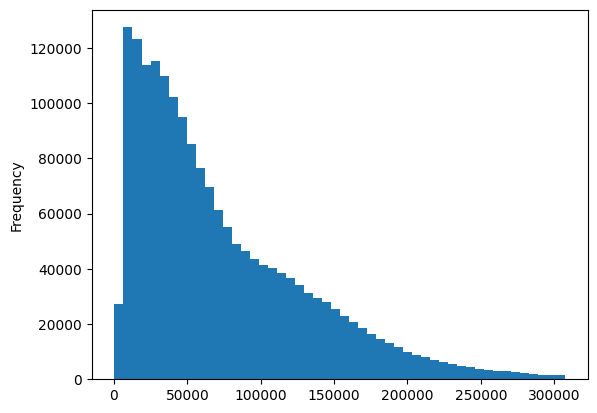

In [13]:
# Distribution of value.
print(gdf_prixbien_clean["value"].describe())
gdf_prixbien_clean["value"].plot.hist(bins=50)

## Preliminary analysis (prixm2)

In [14]:
# Create a prixm2-only GeoDataFrame for analysis.
mask = gdf["metric"] == "prixm2"
gdf_prixm2 = gdf[mask]

count    294336.000000
mean       1525.560334
std         867.121468
min          39.646008
25%        1006.459725
50%        1335.592700
75%        1794.402975
max       24983.373000
Name: value, dtype: float64


<Axes: ylabel='Frequency'>

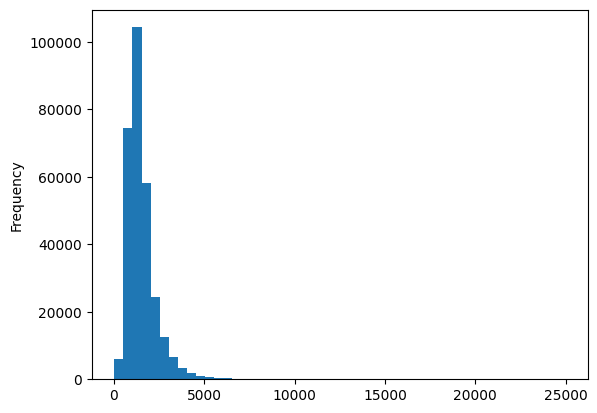

In [15]:
# Distribution of value.
print(gdf_prixm2["value"].describe())
gdf_prixm2["value"].plot.hist(bins=50)


<Axes: xlabel='year'>

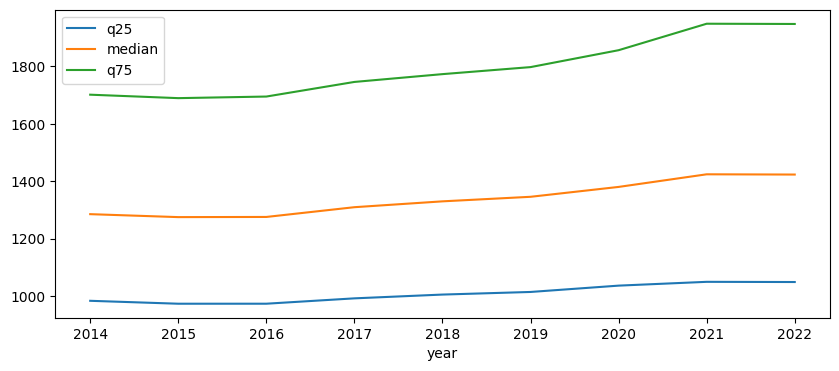

In [16]:
# Distribution of value by year (quartiles).
year_q = (
    gdf_prixm2.groupby("year")["value"]
    .quantile([0.25, 0.5, 0.75])
    .unstack()
)
year_q.columns = ["q25", "median", "q75"]
year_q.plot(figsize=(10, 4))


<Axes: xlabel='dep'>

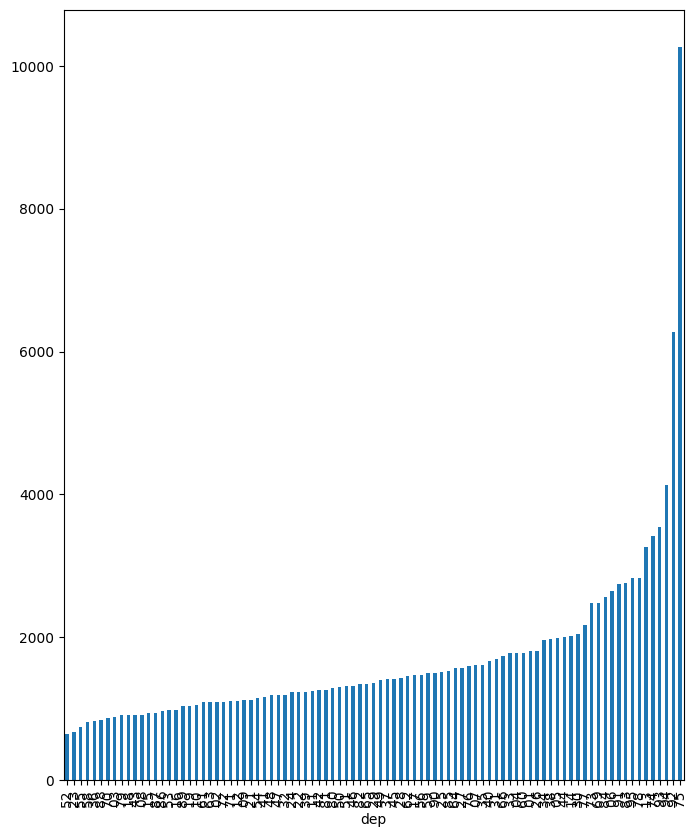

In [17]:
# Distribution of value by dep (median).
dep_median = gdf_prixm2.groupby("dep")["value"].median().sort_values()
dep_median.plot(kind="bar", figsize=(8, 10))


Text(0.5, 1.0, 'Median prixm2 by dep and year (top 20 deps)')

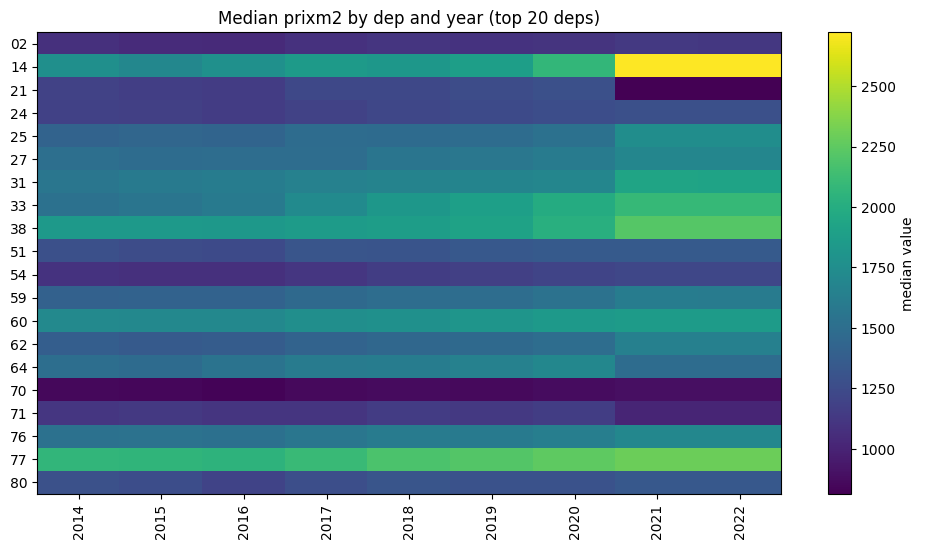

In [18]:
# Distribution of value by dep and year (median heatmap for top deps).
top_deps = (
    gdf_prixm2.groupby("dep")["value"].count().sort_values(ascending=False).head(20).index
)
dep_year = (
    gdf_prixm2[gdf_prixm2["dep"].isin(top_deps)]
    .pivot_table(index="dep", columns="year", values="value", aggfunc="median")
)
plt.figure(figsize=(12, 6))
plt.imshow(dep_year, aspect="auto")
plt.yticks(range(len(dep_year.index)), dep_year.index)
plt.xticks(range(len(dep_year.columns)), dep_year.columns, rotation=90)
plt.colorbar(label="median value")
plt.title("Median prixm2 by dep and year (top 20 deps)")


In [19]:
# Basic outlier cleanup using IQR.
q1 = gdf_prixm2["value"].quantile(0.25)
q3 = gdf_prixm2["value"].quantile(0.75)
iqr = q3 - q1
lower = q1 - 2.5 * iqr
upper = q3 + 2.5 * iqr
gdf_prixm2_clean = gdf_prixm2[gdf_prixm2["value"].between(lower, upper)]
print(
    f"Dropped {len(gdf_prixm2) - len(gdf_prixm2_clean)} rows as outliers,"
    f"{len(gdf_prixm2_clean) / len(gdf_prixm2) - 1}, of the total"
)


Dropped 6205 rows as outliers,-0.021081349206349187, of the total


count    288131.000000
mean       1448.055130
std         632.861243
min          39.646008
25%         999.400115
50%        1320.542700
75%        1754.698900
max        3764.249500
Name: value, dtype: float64


<Axes: ylabel='Frequency'>

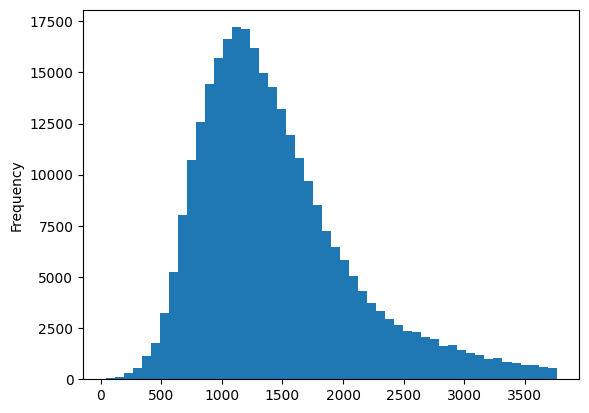

In [20]:
# Distribution of value.
print(gdf_prixm2_clean["value"].describe())
gdf_prixm2_clean["value"].plot.hist(bins=50)

In [21]:
# Testing the merge function with IQR cleaning enabled.
gdf = merge_cic_communes_then_arrondissements(verbose=True, clean_iqr=True)

Dropping the following communes/arrondissements with missing geometry:
<StringArray>
['SANNERVILLE', 'BERNIERES-SUR-SEINE']
Length: 2, dtype: string
Dropped 21,315 rows by IQR cleaning, 0.01, of the total
